## Задание

Распознайте рукописную цифру, написанную на листе от руки.
Последовательность шагов следующая:

*   На бумаге рисуем произвольную цифру (желательно нарисовать цифру размером не
более 5 * 5 мм и без наклона. В занятии нейронка обучалась на цифрах американских студентов. Эти цифры были написаны на тетрадных листах в клетку и имели схожий размер).
*   Фотографируем. Загружаем фото в Collaboratory.
*   С помощью функции image.load_img(path, target_size=(28, 28), color_mode = ‘grayscale’) загружаем картинку в переменную.
*   С помощью функции image.img_to_array(img) преобразуем изображение в numpy-массив.
*   Выполняем инверсию цветов, нормирование и решейп массива.
*   Выполняем распознавание собственной рукописной цифры.

Примечание: точность распознавания рукописных цифр может быть достаточно низкой, т.к. рукописные цифры после преобразований хоть и похожи на содержащиеся в базе, но могут отличаться по конфигурации, толщине линий и т.д.


## Импорт библиотек

In [1]:
import zipfile
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras import utils
from tensorflow.keras.preprocessing import image
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import os
from PIL import Image, ImageOps
import io

## Распаковка архива


In [2]:
!mkdir images

In [3]:
!unzip images.zip -d images/

Archive:  images.zip
 extracting: images/3.png            
 extracting: images/1.png            
 extracting: images/5.png            
 extracting: images/9.png            
 extracting: images/7.png            
 extracting: images/6.png            
 extracting: images/4.png            
 extracting: images/8.png            
 extracting: images/2.png            
 extracting: images/0.png            


## Обработка загруженных изображений

In [4]:
base_dir = 'images'

img_height = 28
img_width = 28

X = []
y = []

for file_name in os.listdir(base_dir):
    if not file_name.lower().endswith('.png'):
        continue

    img_path = os.path.join(base_dir, file_name)

    img = image.load_img(
        img_path,
        target_size=(img_height, img_width),
        color_mode='grayscale'
    )

    image_arr = image.img_to_array(img)
    image_arr = 255 - image_arr
    image_arr = image_arr.astype('float32') / 255.
    image_arr = image_arr.reshape(img_height, img_width, 1)

    X.append(image_arr)

    label = int(os.path.splitext(file_name)[0])
    y.append(label)

X = np.array(X)
y = np.array(y)

print('размер X:', X.shape)
print('размер y:', y.shape)

размер X: (10, 28, 28, 1)
размер y: (10,)


## Визуализация изображений

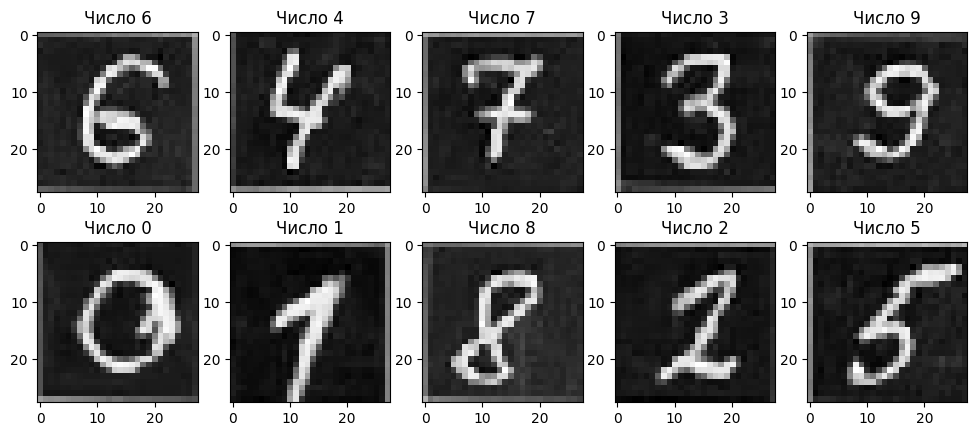

In [5]:
plt.figure(figsize=(12,5))

for i in range(10):
  plt.subplot(2,5,i + 1)
  img = X[i].reshape(28,28)
  plt.imshow(img, cmap='gray')
  plt.title(f"Число {y[i]}")



## Разделение датасета на обучающую и тренировочную выборки

In [6]:
(x_train_org, y_train_org), (x_test_org, y_test_org) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## Вывод размеров выборок

In [7]:
print(f"Размер x_train: {x_train_org.shape}")
print(f"Размер y_train: {y_train_org.shape}")
print()
print(f"Размер x_test: {x_test_org.shape}")
print(f"Размер y_test: {y_test_org.shape}")

Размер x_train: (60000, 28, 28)
Размер y_train: (60000,)

Размер x_test: (10000, 28, 28)
Размер y_test: (10000,)


## Преобразование данных для обучения

In [8]:
CLASS_COUNT = 10 # Количество классов

x_train = x_train_org.reshape(x_train_org.shape[0], -1)
x_test = x_test_org.reshape(x_test_org.shape[0], -1)

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

y_train = utils.to_categorical(y_train_org, CLASS_COUNT)
y_test = utils.to_categorical(y_test_org, CLASS_COUNT)

In [9]:
print(f"Размер y_test: {y_test.shape}")

Размер y_test: (10000, 10)


## Создание модели

In [41]:
model = Sequential()

model.add(Dense(256, input_dim=img_height*img_width, activation='relu'))
model.add(Dense(128, activation='relu'))
model.add(Dense(10, activation='softmax'))

## Компиляция модели

In [43]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

print(model.summary())

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

None


## Обучение модели

In [44]:
history = model.fit(x_train,
          y_train,
          batch_size=256,
          epochs=13,
          validation_data=(x_test, y_test),
          verbose=1)

Epoch 1/13
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9065 - loss: 0.3377 - val_accuracy: 0.9522 - val_loss: 0.1592
Epoch 2/13
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9630 - loss: 0.1264 - val_accuracy: 0.9668 - val_loss: 0.1072
Epoch 3/13
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9765 - loss: 0.0806 - val_accuracy: 0.9715 - val_loss: 0.0883
Epoch 4/13
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9824 - loss: 0.0600 - val_accuracy: 0.9739 - val_loss: 0.0781
Epoch 5/13
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9873 - loss: 0.0441 - val_accuracy: 0.9748 - val_loss: 0.0728
Epoch 6/13
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9906 - loss: 0.0331 - val_accuracy: 0.9798 - val_loss: 0.0687
Epoch 7/13
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9925 - loss: 0.0259 - val_accuracy: 0.9788 - val_loss: 0.0668
Epoch 8/13
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9936 - loss: 0.0211 - val_accuracy: 0

## Значение на тестовой выборке

In [20]:
test_loss, test_acc = model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9829 - loss: 0.0995


In [22]:
print(f"Точность на тестовых данных: {test_acc}")
print(f"Значение loss на тестовых данных: {test_loss}")

Точность на тестовых данных: 0.9829000234603882
Значение loss на тестовых данных: 0.09947630763053894


## Предсказание загруженных картинок

In [23]:
X = X.reshape(X.shape[0], -1)

In [24]:
prediction = model.predict(X)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 456ms/step


In [27]:
preds = np.argmax(prediction, axis=1)
print(f"Числа на картинках распознаны как: {preds}")
print(f"Числа, которые действительно изображены на картинках: {y}")

Числа на картинках распознаны как: [2 8 3 5 9 0 2 8 2 5]
Числа, которые действительно изображены на картинках: [6 4 7 3 9 0 1 8 2 5]


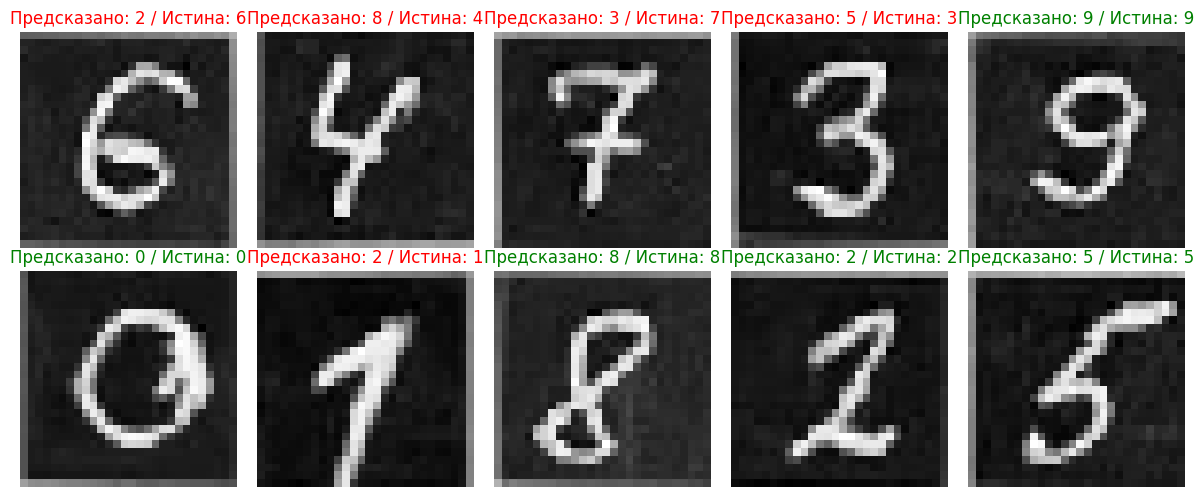

In [30]:
n = 10
rows = 2
cols = 5

plt.figure(figsize=(12, 5))

for i in range(n):
    plt.subplot(rows, cols, i + 1)

    img = X[i].reshape(28, 28)

    pred = preds[i]
    true = y[i]

    color = 'green' if pred == true else 'red'

    plt.imshow(img, cmap='gray')
    plt.title(f"Предсказано: {pred} / Истина: {true}", color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()

## Графики обучения

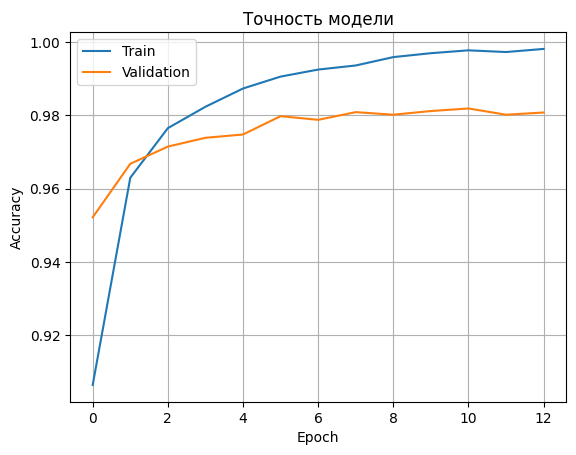

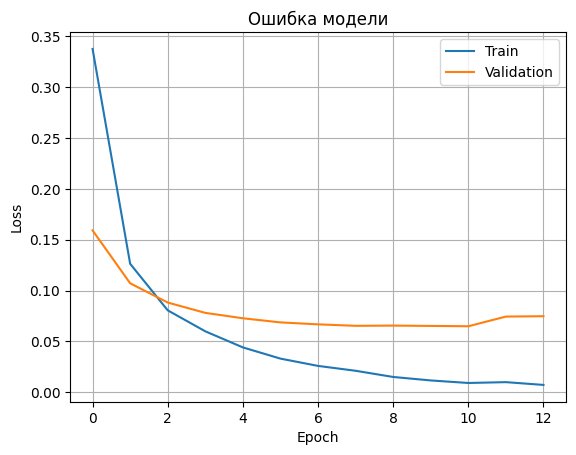

In [45]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Точность модели')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.grid()
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Ошибка модели')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.grid()
plt.show()